1 – Install Libraries

In [1]:
!pip install nltk scikit-learn pandas matplotlib seaborn wordcloud joblib transformers torch tweepy flask pyngrok -q

2 – Imports

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

3 – Upload Dataset

In [3]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("/content/IMDB Dataset.csv")

print(df.head())
print(df.shape)

Saving IMDB Dataset.csv to IMDB Dataset.csv
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
(50000, 2)


4 – Text Preprocessing

In [23]:
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\\S+|www\\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)

    text = text.lower()

    tokens = word_tokenize(text)

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

df['cleaned_review'] = df['review'].apply(clean_text)

df.head()

,review,sentiment,cleaned_review,label
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching episode youll ...,1
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...,1
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,1
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...,1


In [24]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

review = df["review"].iloc[0]

cleaned = re.sub(r"<.*?>", "", review)
cleaned = re.sub(r"http\S+|www\S+", "", cleaned)
cleaned = re.sub(r"[^a-zA-Z\s]", "", cleaned)
cleaned = cleaned.lower().strip()

tokens = word_tokenize(cleaned)

filtered = [word for word in tokens if word not in stop_words and len(word) > 2]

lemmatized = [lemmatizer.lemmatize(word) for word in filtered]

print("="*100)
print("TEXT PREPROCESSING DEMONSTRATION")
print("="*100)

print("\nOriginal Review\n")
print(review)

print("\nCleaning\n")
print(cleaned)

print("\nTokenization\n")
print(tokens)

print("\nStopword Removal\n")
print(filtered)

print("\nLemmatization\n")
print(lemmatized)

print("\nFinal Preprocessed Review\n")
print(" ".join(lemmatized))

TEXT PREPROCESSING DEMONSTRATION

Original Review

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I woul

5 – TF-IDF Vectorization

In [5]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df['cleaned_review'])

print("TF-IDF Matrix Shape:", X.shape)

print("\nSample Features:")
print(vectorizer.get_feature_names_out()[:20])

TF-IDF Matrix Shape: (50000, 10000)

Sample Features:
['aaron' 'abandon' 'abandoned' 'abbott' 'abc' 'ability' 'able' 'able get'
 'able make' 'able see' 'aboard' 'abomination' 'abortion' 'abound'
 'abraham' 'abroad' 'abrupt' 'abruptly' 'absence' 'absent']


In [19]:
# TF-IDF Vectorization

print("="*60)
print("TF-IDF Vectorization Completed")
print("="*60)

print("\nTF-IDF Matrix Shape:")
print(X.shape)

print("\nVocabulary Size:")
print(len(vectorizer.get_feature_names_out()))

print("\nFirst 20 Feature Names:")
print(vectorizer.get_feature_names_out()[:20])

print("\nSample TF-IDF Matrix (First 5 Documents × First 10 Features):")
tfidf_df = pd.DataFrame(
    X[:5, :10].toarray(),
    columns=vectorizer.get_feature_names_out()[:10]
)
print(tfidf_df)

TF-IDF Vectorization Completed

TF-IDF Matrix Shape:
(50000, 10000)

Vocabulary Size:
10000

First 20 Feature Names:
['aaron' 'abandon' 'abandoned' 'abbott' 'abc' 'ability' 'able' 'able get'
 'able make' 'able see' 'aboard' 'abomination' 'abortion' 'abound'
 'abraham' 'abroad' 'abrupt' 'abruptly' 'absence' 'absent']

Sample TF-IDF Matrix (First 5 Documents × First 10 Features):
   aaron  abandon  abandoned  abbott  abc  ability  able  able get  able make  \
0    0.0      0.0        0.0     0.0  0.0      0.0   0.0       0.0        0.0   
1    0.0      0.0        0.0     0.0  0.0      0.0   0.0       0.0        0.0   
2    0.0      0.0        0.0     0.0  0.0      0.0   0.0       0.0        0.0   
3    0.0      0.0        0.0     0.0  0.0      0.0   0.0       0.0        0.0   
4    0.0      0.0        0.0     0.0  0.0      0.0   0.0       0.0        0.0   

   able see  
0       0.0  
1       0.0  
2       0.0  
3       0.0  
4       0.0  


6 – Top Words by Sentiment

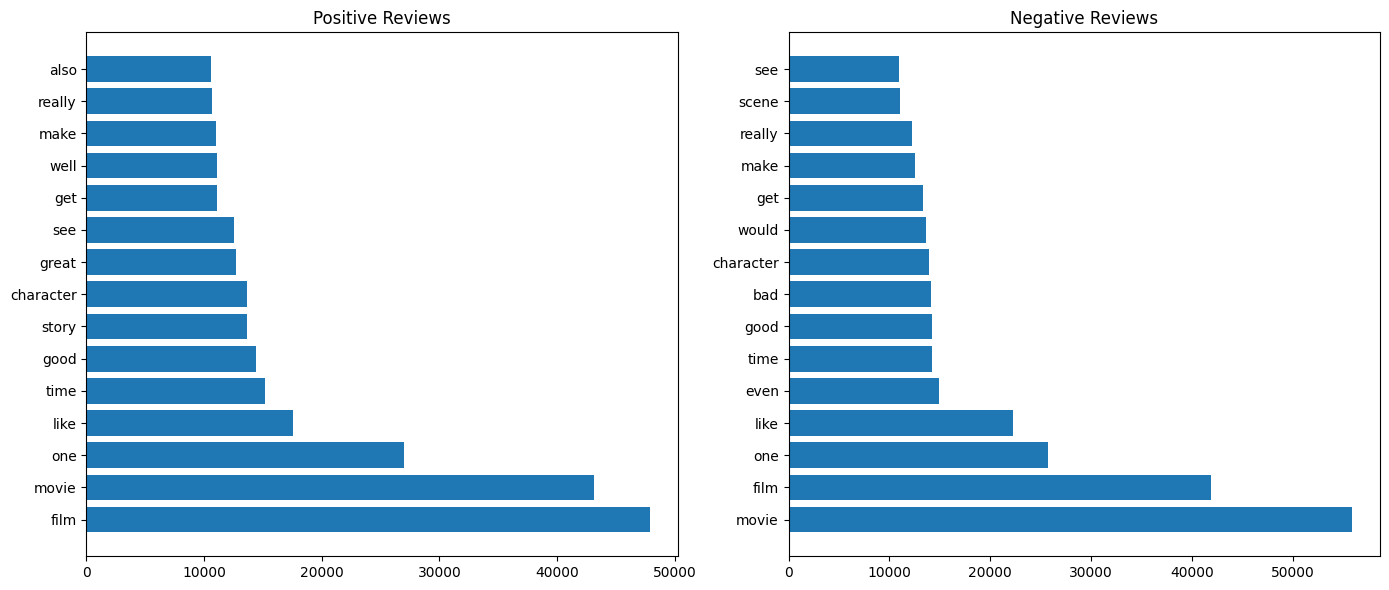

In [6]:
def top_words(sentiment):

    text = " ".join(
        df[df['sentiment']==sentiment]['cleaned_review']
    )

    words = Counter(text.split())

    return words.most_common(15)

positive_words = top_words("positive")
negative_words = top_words("negative")

fig, axes = plt.subplots(1,2, figsize=(14,6))

for ax,data,title in zip(
    axes,
    [positive_words, negative_words],
    ["Positive Reviews","Negative Reviews"]
):

    words = [i[0] for i in data]
    counts = [i[1] for i in data]

    ax.barh(words, counts)

    ax.set_title(title)

plt.tight_layout()

plt.savefig("top_words_by_sentiment.png")

plt.show()

7 – Train Test Split

In [7]:
df['label'] = df['sentiment'].map({
    'negative':0,
    'positive':1
})

X_train,X_test,y_train,y_test = train_test_split(
    df['cleaned_review'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

 8 – Logistic Regression Model

In [8]:
model = Pipeline([
    (
        'tfidf',
        TfidfVectorizer(
            max_features=10000,
            ngram_range=(1,2)
        )
    ),
    (
        'clf',
        LogisticRegression(max_iter=1000)
    )
])

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5000
           1       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



9 – Confusion Matrix

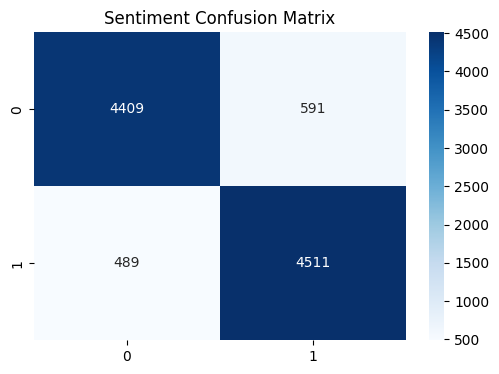

In [9]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Sentiment Confusion Matrix")

plt.savefig("sentiment_confusion_matrix.png")

plt.show()

10 – Positive Word Cloud

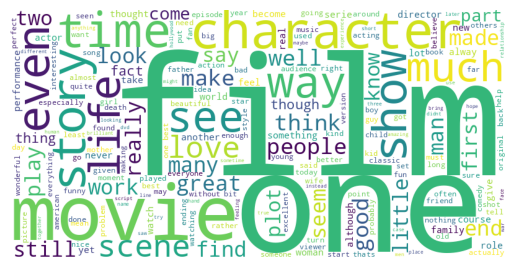

In [10]:
positive_text = " ".join(
    df[df['sentiment']=="positive"]
    ['cleaned_review']
)

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.imshow(wc)

plt.axis("off")

plt.savefig("wordcloud_positive.png")

plt.show()

11 – Negative Word Cloud

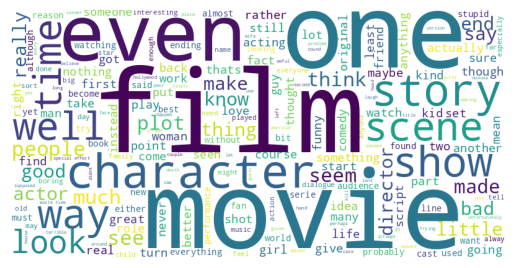

In [11]:
negative_text = " ".join(
    df[df['sentiment']=="negative"]
    ['cleaned_review']
)

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.imshow(wc)

plt.axis("off")

plt.savefig("wordcloud_negative.png")

plt.show()

12 – Feature Importance Chart

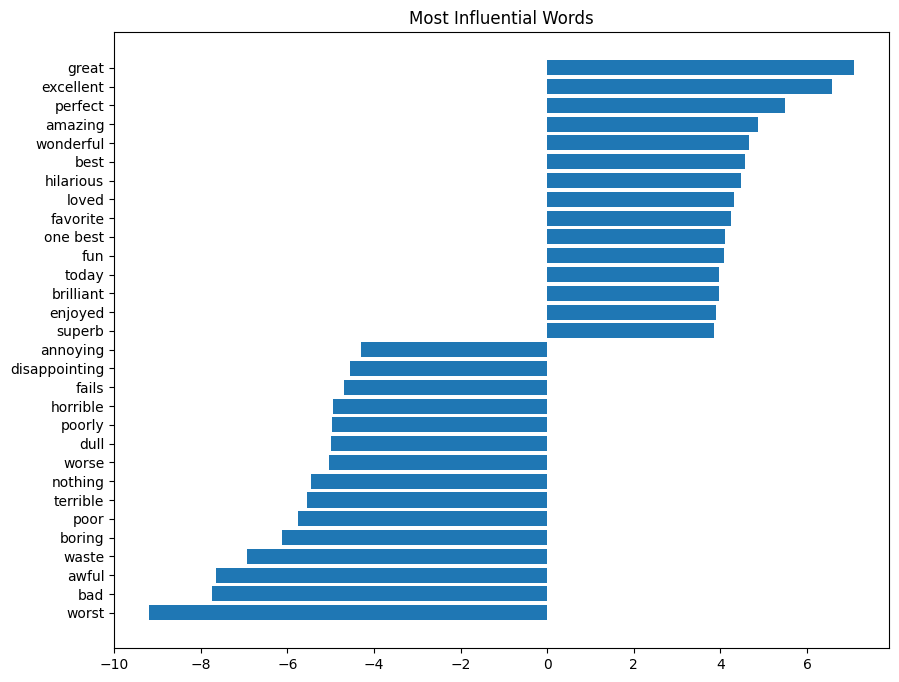

In [12]:
tfidf = model.named_steps['tfidf']
clf = model.named_steps['clf']

feature_names = np.array(
    tfidf.get_feature_names_out()
)

coefs = clf.coef_[0]

top_positive = np.argsort(coefs)[-15:]
top_negative = np.argsort(coefs)[:15]

important = np.concatenate(
    [top_negative, top_positive]
)

plt.figure(figsize=(10,8))

plt.barh(
    feature_names[important],
    coefs[important]
)

plt.title("Most Influential Words")

plt.savefig("feature_importance_nlp.png")

plt.show()

13 – Model Comparison

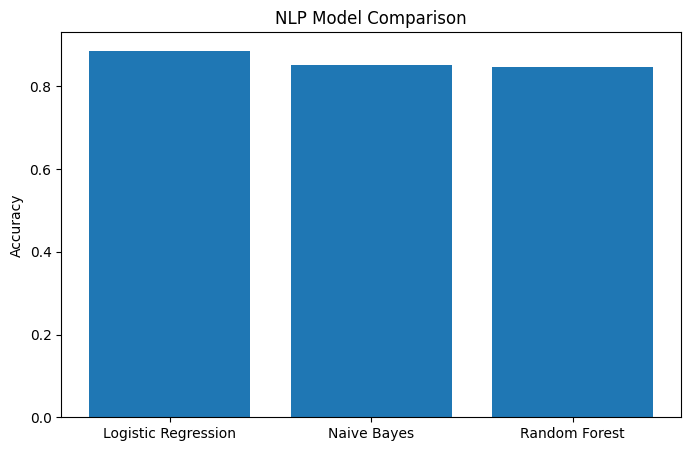

{'Logistic Regression': 0.8864, 'Naive Bayes': 0.8518, 'Random Forest': 0.8468}


In [13]:
models = {

    "Logistic Regression":
        Pipeline([
            ('tfidf',TfidfVectorizer(max_features=5000)),
            ('clf',LogisticRegression(max_iter=1000))
        ]),

    "Naive Bayes":
        Pipeline([
            ('tfidf',TfidfVectorizer(max_features=5000)),
            ('clf',MultinomialNB())
        ]),

    "Random Forest":
        Pipeline([
            ('tfidf',TfidfVectorizer(max_features=5000)),
            ('clf',RandomForestClassifier(n_estimators=100))
        ])
}

scores = {}

for name,m in models.items():

    m.fit(X_train,y_train)

    pred = m.predict(X_test)

    scores[name] = accuracy_score(
        y_test,
        pred
    )

plt.figure(figsize=(8,5))

plt.bar(
    scores.keys(),
    scores.values()
)

plt.ylabel("Accuracy")

plt.title("NLP Model Comparison")

plt.savefig("nlp_model_comparison.png")

plt.show()

print(scores)

Evaluation Metrics

In [21]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy")

print(accuracy_score(y_test,y_pred))

print("\n")

print(classification_report(y_test,y_pred))

print("\n")

print(confusion_matrix(y_test,y_pred))

Accuracy
0.892


              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5000
           1       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



[[4409  591]
 [ 489 4511]]


14 – Save Model

In [28]:
joblib.dump(
    model,
    "sentiment_model.pkl"
)

print("Model Saved")

Model Saved


BONUS 1 –  Class Sentiment

In [ ]:
from textblob import TextBlob

def convert_three_class(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0.2:
        return "positive"

    elif polarity < -0.2:
        return "negative"

    else:
        return "neutral"

df['three_class'] = df['review'].apply(
    convert_three_class
)

df['three_class'].value_counts()

,count
three_class,
neutral,35448
positive,12845
negative,1707


BONUS 2 – Real Time Sentiment Analyzer

In [16]:

while True:

    text = input("Enter Review:")

    if text.lower()=="exit":
        break

    prediction = model.predict([text])[0]

    print(
        "Positive"
        if prediction==1
        else "Negative"
    )

Enter Review:great 
Positive
Enter Review:well
Positive
Enter Review:bad
Negative
Enter Review:although
Positive
Enter Review:perfromance
Negative


KeyboardInterrupt: Interrupted by user

BONUS 4 – BERT Sentiment Analysis

In [18]:
from transformers import pipeline

bert = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

text = "This movie was fantastic!"

result = bert(text)[0]

print("Review:", text)
print("Prediction:", result["label"])
print("Confidence:", round(result["score"]*100,2), "%")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Review: This movie was fantastic!
Prediction: POSITIVE
Confidence: 99.99 %
